# **Нелинейные модели против южной погоды**

#### Описание исследования.
- Обучить минимум 2 нелинейные модели: kNN Regressor и Decision Tree Regressor.
- `Rented Bike Count` — это целевая переменная. Она содержит количество велосипедов, арендованных за конкретный час.
- Оценка модели по ключевой метрике RMSE. Вспомогательные метрики качества: R² и MAE.
- Значение RMSE лучшей модели должно быть не меньше, чем у предоставленной линейной модели.
#### Цель исследования
- Повысить точность прогнозов.
- Оптимизировать логистику распределения велосипедов.
- Улучшить клиентский опыт, избегая простоев и дефицита.
#### Задачи исследования.
- 1. Работа с базовой моделью
- 1.1. Загрузка и подготовка данных
- 2. Улучшение модели — kNN и дерево решений
- 2.1. Предобработка
- 2.2. Исследовательский анализ данных
- 2.3. Обучение KNN и Decision Tree
- 2.4. Подбор гиперпараметров
- 2.5. Сравнение с линейной моделью
- 2.6. Выводы
#### Исходные данные.
- `baseline_linear_regression_pipeline.pkl`	- Базовый пайплайн линейной регрессии.
- `ds_s14_train_data.csv`	- Датасет для обучения и валидации модели.
- `ds_s14_test_data.csv`	- Датасет нужен только для финальной проверки модели и итоговой оценки её качества.

## **Часть 1. Работа с базовой моделью**

Сперва вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSouth до того, как обратилась к вам.

Компания предоставила:

* Pickle-файл — готовый обученный пайплайн без исходного кода. Доступен по пути здесь: `'/datasets/baseline_linear_regression_pipeline.pkl'`.

* Тренировочную и тестовую выборки, которые можно использовать для оценки модели. Они расположены здесь:

  * `'/datasets/ds_s14_train_data.csv'`;
  * `'/datasets/ds_s14_test_data.csv'`.


Базовую модель не нужно обучать заново — достаточно загрузить её и проверить качество.

**Совет:**
1. Убедитесь, что у вас есть доступ к `baseline_linear_regression_pipeline.pkl`, `ds_s14_train_data.csv` и `ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки `X` и целевую переменную `y`.

3. Загрузите .pkl-файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R² — эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

>Техническая напоминание: для работы с PKL-файлом нужно установить библиотеку joblib.

In [1]:
from pandas import DataFrame
from pandas.core.common import random_state
!pip install "scikit-learn==1.6.1" "numpy==2.4.3" "optuna==4.8.0" -U -q
!pip install phik -U -q
!pip install ipywidgets -U -q

ERROR: Ignored the following versions that require a different python version: 1.7.0 Requires-Python >=3.10; 1.7.0rc1 Requires-Python >=3.10; 1.7.1 Requires-Python >=3.10; 1.7.2 Requires-Python >=3.10; 1.8.0 Requires-Python >=3.11; 1.8.0rc1 Requires-Python >=3.11; 2.1.0 Requires-Python >=3.10; 2.1.1 Requires-Python >=3.10; 2.1.2 Requires-Python >=3.10; 2.1.3 Requires-Python >=3.10; 2.2.0 Requires-Python >=3.10; 2.2.1 Requires-Python >=3.10; 2.2.2 Requires-Python >=3.10; 2.2.3 Requires-Python >=3.10; 2.2.4 Requires-Python >=3.10; 2.2.5 Requires-Python >=3.10; 2.2.6 Requires-Python >=3.10; 2.3.0 Requires-Python >=3.11; 2.3.1 Requires-Python >=3.11; 2.3.2 Requires-Python >=3.11; 2.3.3 Requires-Python >=3.11; 2.3.4 Requires-Python >=3.11; 2.3.5 Requires-Python >=3.11; 2.4.0 Requires-Python >=3.11; 2.4.0rc1 Requires-Python >=3.11; 2.4.1 Requires-Python >=3.11; 2.4.2 Requires-Python >=3.11; 2.4.3 Requires-Python >=3.11; 2.4.4 Requires-Python >=3.11
ERROR: Could not find a version that satisf

In [2]:
#Импорт библиотек
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import phik
from time import time
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    root_mean_squared_error,
    mean_squared_error,
    r2_score
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.inspection import permutation_importance
import numpy as np
import joblib
import optuna

In [3]:
# Зафиксируем константы для воспроизводимости
RANDOM_STATE = 42
N_FOLDS = 5

#### 1.1 Загрузка линейного пайплайна

In [4]:
#Загрузка пайплайна из файла
try:
    loaded_pipeline = joblib.load('/datasets/baseline_linear_regression_pipeline.pkl')
except FileNotFoundError:
    loaded_pipeline = joblib.load('datasets/baseline_linear_regression_pipeline.pkl')

#### 1.2 Загрузка данных

In [5]:
datasets = dict(
    links=dict(
        train='datasets/ds_s14_train_data.csv',
        test='datasets/ds_s14_test_data.csv',
    )
)
for name, link in datasets['links'].items():
    try:
        link = '/' + datasets['links'][name]
        datasets[name] = pd.read_csv(link, sep=',', decimal='.')
        print(f'Загружен файл {link}')
    except FileNotFoundError as e:
        print(f'Ошибка загрузки файла {link}')
        datasets[name] = pd.read_csv(datasets['links'][name], sep=',', decimal='.')
        print(f'Загружен файл {datasets['links'][name]}')

Ошибка загрузки файла /datasets/ds_s14_train_data.csv
Загружен файл datasets/ds_s14_train_data.csv
Ошибка загрузки файла /datasets/ds_s14_test_data.csv
Загружен файл datasets/ds_s14_test_data.csv


In [6]:
#Загрузка разделенных данных train и test
X_train_init = datasets['train'].drop(columns=['Rented Bike Count'])
y_train_init = datasets['train']['Rented Bike Count']
X_train = X_train_init.copy()
y_train = y_train_init.copy()
X_test = datasets['test'].drop(columns=['Rented Bike Count'])
y_test = datasets['test']['Rented Bike Count']

In [7]:
#Оценка обхема загруженных данных
print(f'Объем данных для X_train: {X_train.shape}')
print(f'Объем данных для y_train: {y_train.shape}')
print(f'Объем данных для X_test: {X_test.shape}')
print(f'Объем данных для y_test: {y_test.shape}')

Объем данных для X_train: (7008, 15)
Объем данных для y_train: (7008,)
Объем данных для X_test: (1752, 15)
Объем данных для y_test: (1752,)


#### 1.3 Получение метрик линейной модели

In [8]:

def evaluate_model(pipe, X_tmp, y_tmp, train=True):
    y_pred_tmp = pipe.predict(X_tmp)

    rmse=root_mean_squared_error(y_tmp, y_pred_tmp)
    mse=mean_squared_error(y_tmp, y_pred_tmp)
    r2=r2_score(y_tmp, y_pred_tmp)
    name = 'тренировочной'
    if not train:
        name = 'тестовой'

    print(f"RMSE на {name} выборке:", round(rmse,3))
    print(f"MSE на {name} выборке:", round(mse,3))
    print(f"R2 на {name} выборке:", round(r2,3))


In [9]:
# Метрики линейной модели на train
evaluate_model(loaded_pipeline, X_train, y_train)

RMSE на тренировочной выборке: 412.526
MSE на тренировочной выборке: 170177.993
R2 на тренировочной выборке: 0.593


In [10]:
# Метрики линейной модели на test
evaluate_model(loaded_pipeline, X_test, y_test, False)

RMSE на тестовой выборке: 411.564
MSE на тестовой выборке: 169384.999
R2 на тестовой выборке: 0.586


## **Часть 2. Улучшение модели — kNN и дерево решений**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы погоды и поведение клиентов.

Вы будете экспериментировать с моделями kNN и деревьями решений, используя подбор гиперпараметров Optuna.

**Шаг 1. Изучение данных**

Проведите исследовательский анализ данных:
1. Посмотрите на распределение целевой переменной `Rented Bike Count`. Определите, есть ли у неё выбросы или сильные сезонные колебания.
2. Постройте графики зависимости спроса от разных признаков.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Рассчитайте корреляцию между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять: начните с базовых графиков и описательной статистики.

### 2.1 Предобработка данных

In [11]:
datasets['train'].info()

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

In [12]:
datasets['train'].head()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


Датасет ds_s14_train_data.csv содержит 16 столбцов и 7008 строк, в которых представлена информация о посещениях сайтов пользователями.

После первичного анализа данных можно сделать следующие выводы:

Названия столбцов нужно привести к виду snake_case.
Столбцы `Temperature`,  `Wind speed (m/s)`,  `Dew point temperature`, `Solar Radiation (MJ/m2)`, `Rainfall(mm)`, `Snowfall (cm)` содержат числа с плавающей точкой и хранятся в типе данных `float64`, их размерность можно оптимизировать.
Столбцы `Humidity(%)` и `Visibility (10m)` содержат числа с плавающей точкой и хранятся в типе данных `float64`, их размерность можно оптимизировать и и привести к типу данных `int`.
Столбцы `Seasons`, `Holiday` и `Functioning Day` содержат категориальную информацию с хранятся в типе данных `str`, тип данных следует преобразовать в `category`.
Столбцы `Time_Period_Evening`, `Time_Period_Late Evening`, `Time_Period_Morning`, `Time_Period_Night` содержат категориальную информацию с хранятся в типе данных `bool`.
Столбец `Rented Bike Count` содержит целочисленные значения которые хранятся в типе данных `int64`.

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.



---



**Шаг 2. Разделение данных на тренировочную и валидационную выборки**

Используйте на этом этапе данные файла `ds_s14_train_data.csv`. Тестовый набор нужен только для финальной оценки модели после обучения и подбора гиперпараметров.

Подготовка данных вам понадобится, чтобы обучить модель и оценить её качество через валидацию.

---



In [13]:
# Приведение имен колонок к snake_case
datasets['train'].columns = datasets['train'].columns.str.lower().str.replace(' ', '_')
datasets['test'].columns = datasets['test'].columns.str.lower().str.replace(' ', '_')
df_train = datasets['train']
df_test = datasets['test']

In [14]:
#Загрузка разделенных данных train и test
X_train = datasets['train'].drop(columns=['rented_bike_count'])
y_train = datasets['train']['rented_bike_count']
X_test = datasets['test'].drop(columns=['rented_bike_count'])
y_test = datasets['test']['rented_bike_count']

In [15]:
# Класс оптимизации типов данных датафрейма
class DataFrameNormalizer:
    def __init__(self, df):
        self.df = df

    def run(self,
        to_int: list = None,
        to_float: list = None,
        to_category: list = None,
        to_date: list = None
    ) -> pd.DataFrame:
        original_df = self.df.copy()
        if to_int:
            self.to_int(to_int)
        if to_float:
            self.to_float(to_float)
        if to_category:
            self.to_category(to_category)
        if to_date:
            self.to_date(to_date)
        return pd.concat([
            original_df.dtypes.rename('До изменений'),
            self.df.dtypes.rename('После изменений')
        ], axis=1)

    def to_int(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='integer')

    def to_float(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='float')

    def to_category(self, columns: list) -> None:
        for column in columns:
            self.df[column] = self.df[column].astype('category')

    def to_date(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_datetime(self.df[column].astype(str))

In [16]:
floats = [
    'temperature',
    'wind_speed_(m/s)',
    'dew_point_temperature',
    'solar_radiation_(mj/m2)',
    'rainfall(mm)',
    'snowfall_(cm)',
]
ints = [
    'humidity(%)',
    'visibility_(10m)'
]
cats = [
    'seasons',
    'holiday',
    'functioning_day',
    'time_period_evening',
    'time_period_late_evening',
    'time_period_morning',
    'time_period_night'
]
DataFrameNormalizer(X_train).run(to_int=ints, to_category=cats, to_float=floats)

,До изменений,После изменений
temperature,float64,float32
humidity(%),float64,float64
wind_speed_(m/s),float64,float32
visibility_(10m),float64,float64
dew_point_temperature,float64,float32
solar_radiation_(mj/m2),float64,float32
rainfall(mm),float64,float32
snowfall_(cm),float64,float32
seasons,str,category
holiday,str,category


In [17]:
class DataFrameReporter:
    def __init__(self, float_format='0.05f', percent_format='0.02%', include_all=False):
        self.float_format = float_format
        self.percent_format = percent_format
        self.include_all = include_all

    def show_report(self, df, title=None):
        if title:
            print(title)
        print('Количество столбцов:', df.shape[1])
        print('Количество строк:', df.shape[0])
        duplicates = df.duplicated().sum()
        print('Количество дубликатов:', duplicates)
        print('Доля дубликатов:', format(duplicates / df.shape[0], self.percent_format))
        display(df.describe(include='all' if self.include_all else None).T)
        print('Количество пропусков:', df.isna().sum().sum())

        isna = df.isna().mean(axis=None).sum()
        print('Доля пропусков:', format(isna, self.float_format))

    @staticmethod
    def count_duplicates(df, columns):
        duplicates_per_column = {col: df[col].duplicated().sum() for col in df.columns}
        duplicates_per_column_stats = pd.DataFrame.from_dict(
            duplicates_per_column, orient='index', columns=['Количество дубликатов']
        )
        return duplicates_per_column_stats.style.background_gradient(
            cmap='coolwarm'
        ).set_caption("Статистика дубликатов по столбцам")

    @staticmethod
    def show_implicit_duplicates_stats(df, columns):
        duplicates = {
            col: df[col].nunique() - df[col].str.strip().str.lower().nunique()
            for col in columns
        }
        duplicates_stats = pd.DataFrame(
            list(duplicates.items()), columns=["Столбец", "Неявных дубликатов"]
        )
        return duplicates_stats.style.background_gradient(
            cmap='coolwarm'
        ).set_caption("Статистика неявных дубликатов")

In [18]:
#Выведем отчет по датасету X_train
reporter = DataFrameReporter(float_format='0.03f', percent_format='0.02%')
reporter.show_report(X_train, 'Отчёт по X_train датасету:')

Отчёт по X_train датасету:
Количество столбцов: 15
Количество строк: 7008
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,mean,std,min,25%,50%,75%,max
temperature,7008.0,12.812914,11.924688,-17.5,3.3,13.50,22.40,39.400002
humidity(%),6758.0,58.200503,20.340317,0.0,42.0,57.00,74.00,98.000000
wind_speed_(m/s),6798.0,1.725228,1.042956,0.0,0.9,1.50,2.30,7.400000
visibility_(10m),6749.0,1435.156764,607.291049,27.0,936.0,1691.00,2000.00,2000.000000
dew_point_temperature,7008.0,4.021490,13.033377,-30.6,-4.7,5.00,14.80,26.799999
solar_radiation_(mj/m2),6798.0,0.569885,0.866142,0.0,0.0,0.01,0.94,3.520000
rainfall(mm),6746.0,0.146902,1.164118,0.0,0.0,0.00,0.00,35.000000
snowfall_(cm),6745.0,0.074752,0.438189,0.0,0.0,0.00,0.00,8.800000


Количество пропусков: 1454
Доля пропусков: 0.014


##### Промежуточный вывод
В результате предобработки данных были выполнены следующие действия:

Изучены пропуски в данных. Пропуски обнаружилось 1454 пропуска что составляет от 1.4% данных.
Данные проверили на явные дубликаты — в данных их не обнаружено.

### 2.2 Исследовательский анализ данных

#### 2.2.1 Описание базовлой информации о датасете
Датасет содержит 68 столбцов и 6146 строк, в которых представлена информация о профилях пользователей.

В датасете представлено 8 числовыех признака:
'temperature',
'wind_speed_(m/s)',
'dew_point_temperature',
'solar_radiation_(mj/m2)',
'rainfall(mm)',
'snowfall_(cm)',
'humidity(%)',
'visibility_(10m)'

1 категориальный признак:
'seasons',

6 бинарный признак:
'holiday',
'functioning_day',
'time_period_evening',
'time_period_late_evening',
'time_period_morning',
'time_period_night'

#### 2.2.2 Анализ целевой переменной

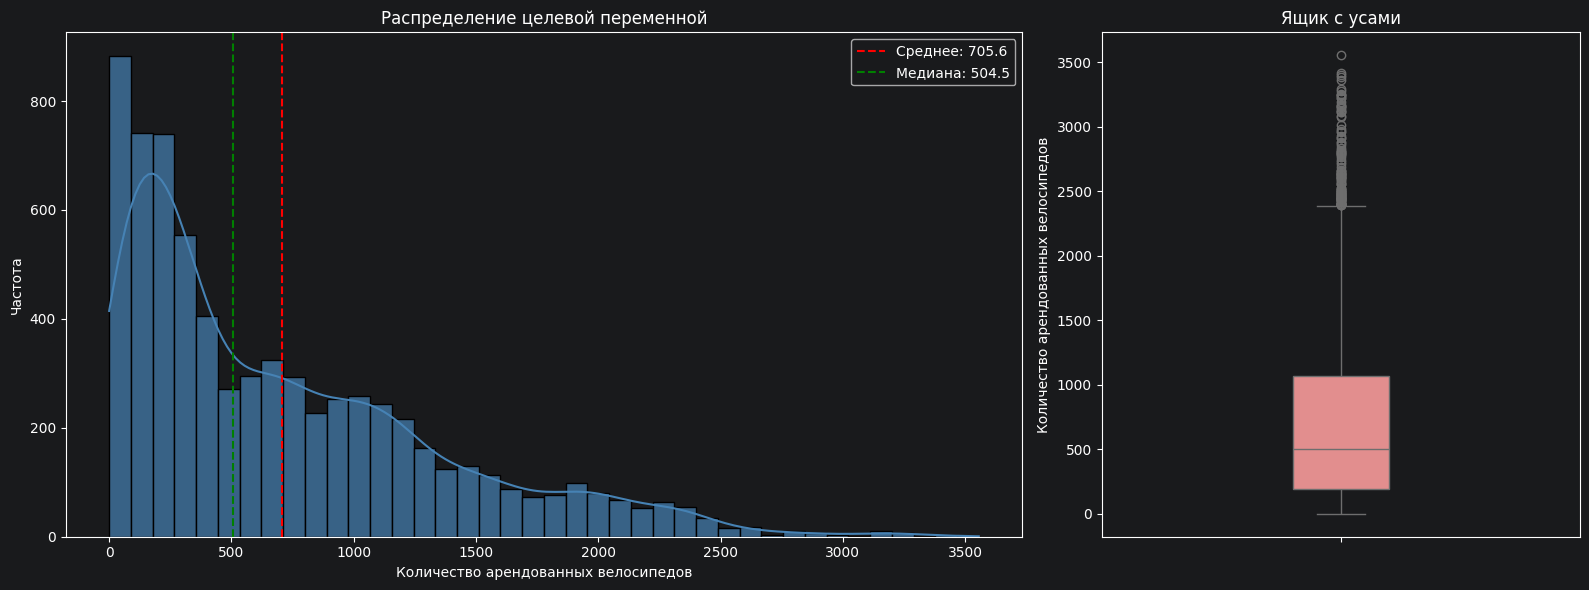

In [19]:
# Распределение количества арендованых велосипедов
fig, axes = plt.subplots(
        1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]}
)

sns.histplot(data=X_train, x=y_train, bins=40, kde=True,
             color='steelblue', ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('Количество арендованных велосипедов')
axes[0].set_ylabel('Частота')
axes[0].axvline(y_train.mean(), color='red', linestyle='--',
                label=f'Среднее: {y_train.mean():.1f}')
axes[0].axvline(y_train.median(), color='green', linestyle='--',
                label=f'Медиана: {y_train.median():.1f}')
axes[0].legend()

sns.boxplot(y=y_train, ax=axes[1], color='lightcoral', width=0.2)
axes[1].set_title('Ящик с усами')
axes[1].set_ylabel('Количество арендованных велосипедов')

plt.tight_layout()
plt.show()

На распределении видим основную массу аренд велосипедов в диапазоне от 0 до 500. Среднее количество аренд 705, а медиана на отметке 504, что может говорить о значительных выбросах, выбросы можем увидеть на ящике с усами выше.

#### 2.2.3 Анализ пропущенных значений

In [20]:
# Сколько строк имеют хотя бы один пропуск
rows_with_nan = df_train.isna().any(axis=1).sum()
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_nan} из {len(df_train)} "
      f"({rows_with_nan/len(df_train)*100:.2f}%)")


Строк с хотя бы одним пропуском: 1334 из 7008 (19.04%)


In [21]:
# Посчитаем количество и доли пропусков в столбцах
def show_missing_stats(tmp_df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp_df.isnull().sum(),
        'Доля пропусков': tmp_df.isnull().mean().round(4)
    })
    missing_stats = missing_stats[
        missing_stats['Кол-во пропусков'] > 0
    ].sort_values(by='Кол-во пропусков', ascending=False)
    return missing_stats.style.background_gradient(
        cmap='coolwarm'
    ) if not missing_stats.empty else "Пропусков в данных нет"
show_missing_stats(df_train)

,Кол-во пропусков,Доля пропусков
snowfall_(cm),263,0.037500
rainfall(mm),262,0.037400
visibility_(10m),259,0.037000
humidity(%),250,0.035700
wind_speed_(m/s),210,0.030000
solar_radiation_(mj/m2),210,0.030000


В датафрейме df_train обнаружено

- 263 пропусков в столбце snowfall_(cm) — это 3% данных. Пропуски в этом столбце, вероятно, связаны с тем, что снега не было. пропуски можно заменить на медиану по сезону.
- 262 пропусков в столбце rainfall(mm) - это 3% данных. Пропуски в этом столбце, вероятно, связаны с тем, дождя не было, пропуски можно заменить на медиану  по сезону.
- 259 пропусков в столбце visibility_(10m) - это 3% данных. Пропуски в этом столбце, вероятно, с тем что данные были повреждены или потеряны. Пропуски заменим на медиану по сезону.
- 250 пропусков в столбце humidity(%) - это 3% данных. Пропуски в этом столбце, вероятно, с тем что данные были повреждены или потеряны. пропуски можно расчитать по формуле вычисления относительной влажности в зависимости от температуры и точки росы.
- 210 пропусков в столбце wind_speed_(m/s) - это 3% данных. Пропуски в этом столбце, вероятно, , с тем что данные были повреждены или потеряны. Пропуски заменим на медиану по сезону.
- 210 пропусков в столбце solar_radiation_(mj/m2) - это 3% данных. Пропуски в этом столбце, вероятно, с тем что данные были повреждены или потеряны. Пропуски заменим на медиану по сезону.

#### 2.2.4 Анализ категориальных признаков

In [22]:
# Посчитаем количество уникальных значений в категориальных столбцах
categories = (
    'seasons',
    'holiday',
    'functioning_day',
    'time_period_evening',
    'time_period_late_evening',
    'time_period_morning',
    'time_period_night'
)
def show_uniques_stats(tmp_df, columns):
    uniques = {}
    unique_values = {}
    for col in columns:
        uniques[col] = tmp_df[col].nunique()
        unique_values[col] = ', '.join([str(x) for x in tmp_df[col].unique()])
    uniques_stats = pd.DataFrame(
        list(uniques.items()),
        columns=['Столбец', 'Уникальных значений']
    )
    uniques_stats['Уникальные значения'] = uniques_stats['Столбец'].map(unique_values)

    return uniques_stats.style.background_gradient(
        cmap='coolwarm'
    ).set_caption('Статистика уникальных значений')
show_uniques_stats(df_train, categories)

,Столбец,Уникальных значений,Уникальные значения
0,seasons,4,"Autumn, Winter, Summer, Spring"
1,holiday,2,"Holiday, No Holiday"
2,functioning_day,2,"Yes, No"
3,time_period_evening,2,"True, False"
4,time_period_late_evening,2,"False, True"
5,time_period_morning,2,"False, True"
6,time_period_night,2,"False, True"


In [23]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   temperature               7008 non-null   float32 
 1   humidity(%)               6758 non-null   float64 
 2   wind_speed_(m/s)          6798 non-null   float32 
 3   visibility_(10m)          6749 non-null   float64 
 4   dew_point_temperature     7008 non-null   float32 
 5   solar_radiation_(mj/m2)   6798 non-null   float32 
 6   rainfall(mm)              6746 non-null   float32 
 7   snowfall_(cm)             6745 non-null   float32 
 8   seasons                   7008 non-null   category
 9   holiday                   7008 non-null   category
 10  functioning_day           7008 non-null   category
 11  time_period_evening       7008 non-null   category
 12  time_period_late_evening  7008 non-null   category
 13  time_period_morning       7008 non-null   category
 14  tim

#### 2.2.5 Анализ выбросов и распределений

In [24]:
# Функция для отрисовки распределения по
def plot_distribution(
        tmp_df, cols,
        figsize=(16, 6), fontsize=12, bins=40, density=True
):
    y_label = 'Плотность'
    if not density:
        y_label = 'Частота'
    for col in cols:
        fig, axes = plt.subplots(
            1, 2, figsize=figsize, gridspec_kw={'width_ratios': [2, 1]}
        )
        data = tmp_df[col].dropna()
        ax1 = axes[0]
        ax1.hist(
            data, bins=bins, alpha=0.5, label=col,
            color='steelblue', edgecolor='black', density=density
            )
        ax1.set_title(f'Распределение {col}', fontsize=fontsize, fontweight='bold')
        ax1.set_xlabel(col)
        ax1.set_ylabel(y_label)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = axes[1]
        box = ax2.boxplot(data, vert=True, patch_artist=True)

        ax2.set_xlabel(col)
        ax2.set_title('Ящик с усами', fontsize=fontsize, fontweight='bold')
        ax2.grid(True, alpha=0.2, axis='x')

        for patch in box['boxes']:
            patch.set_facecolor('lightcoral')
            patch.set_alpha(0.7)

        plt.tight_layout()
        plt.show()

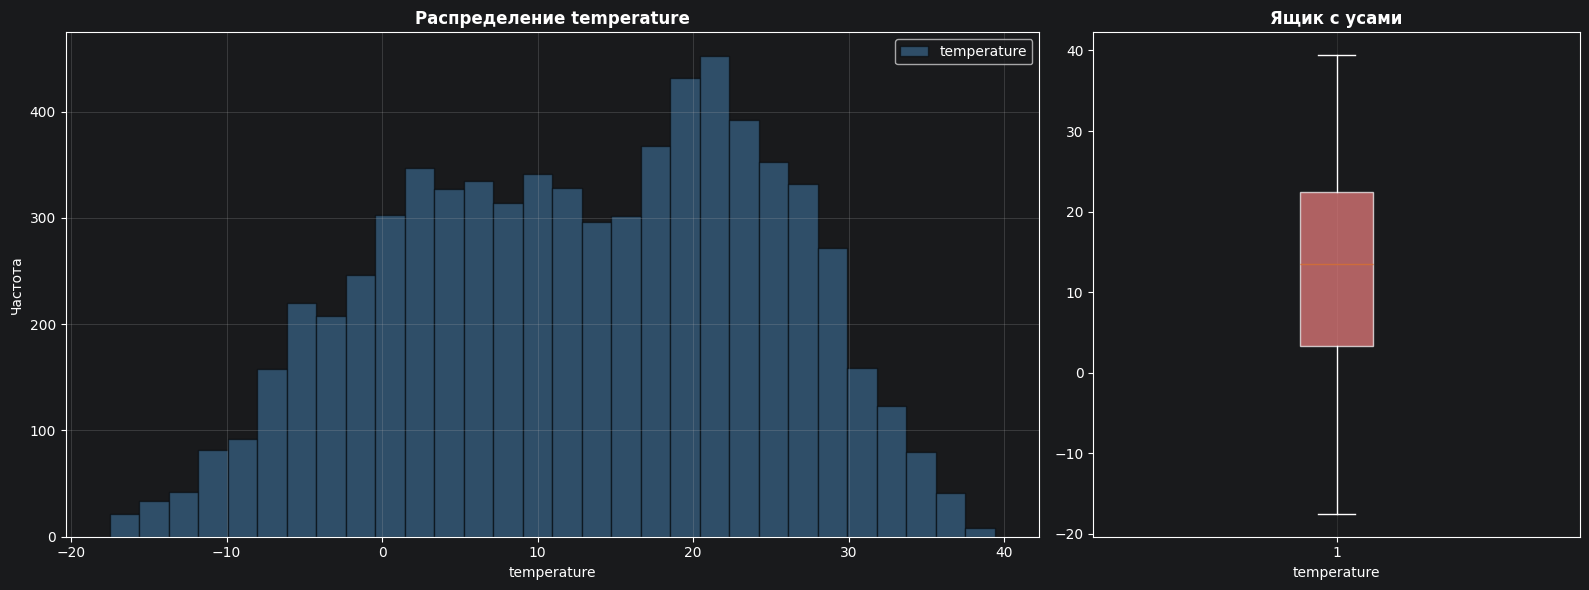

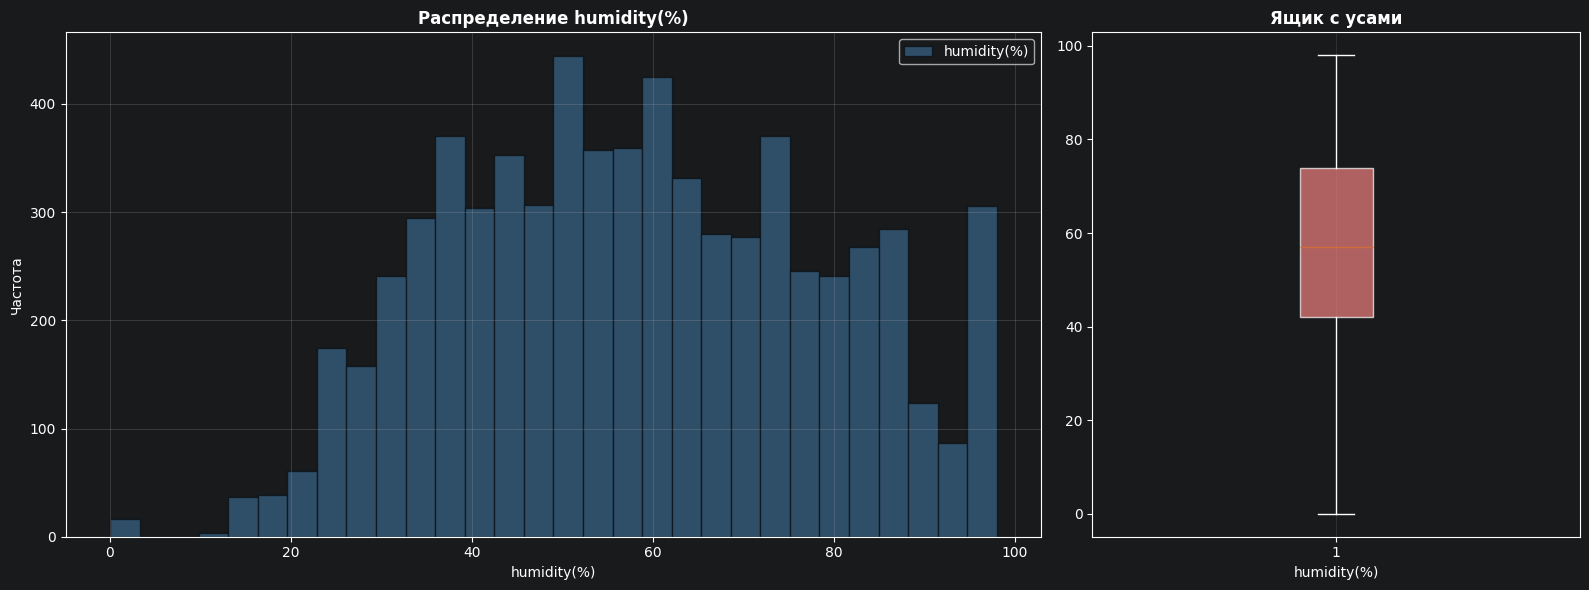

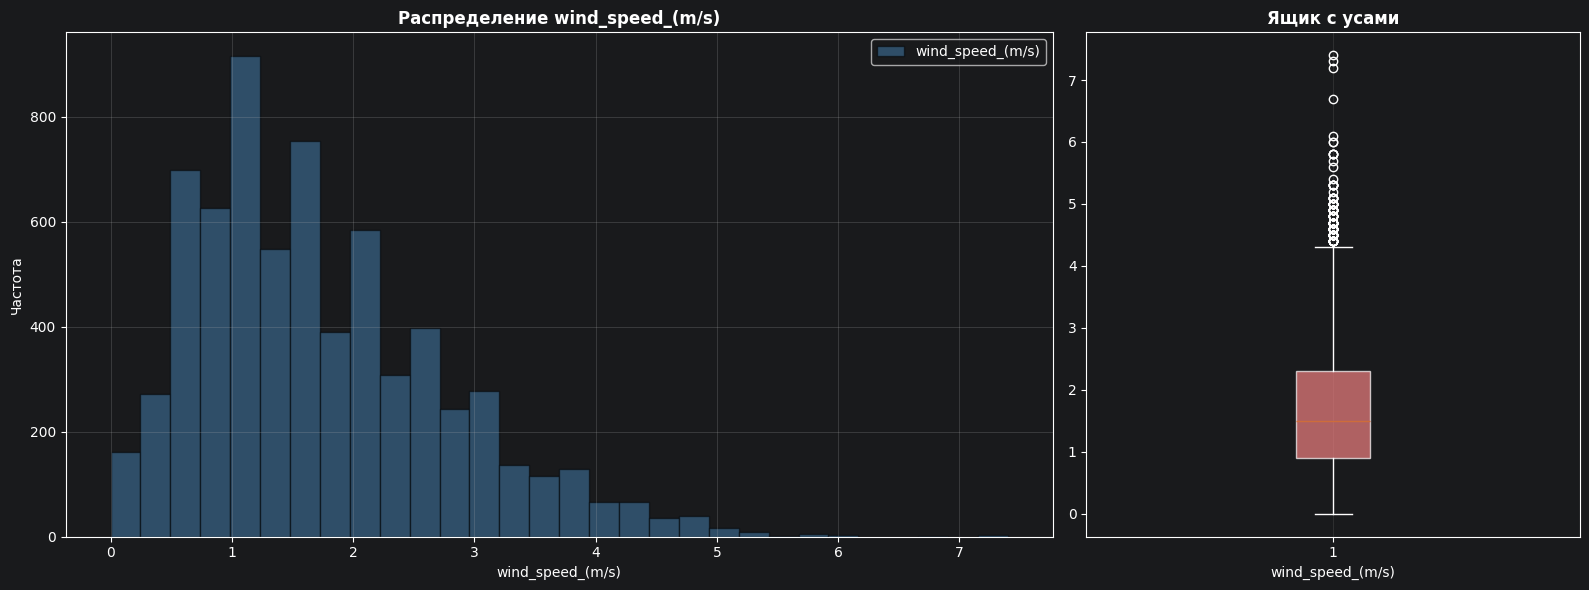

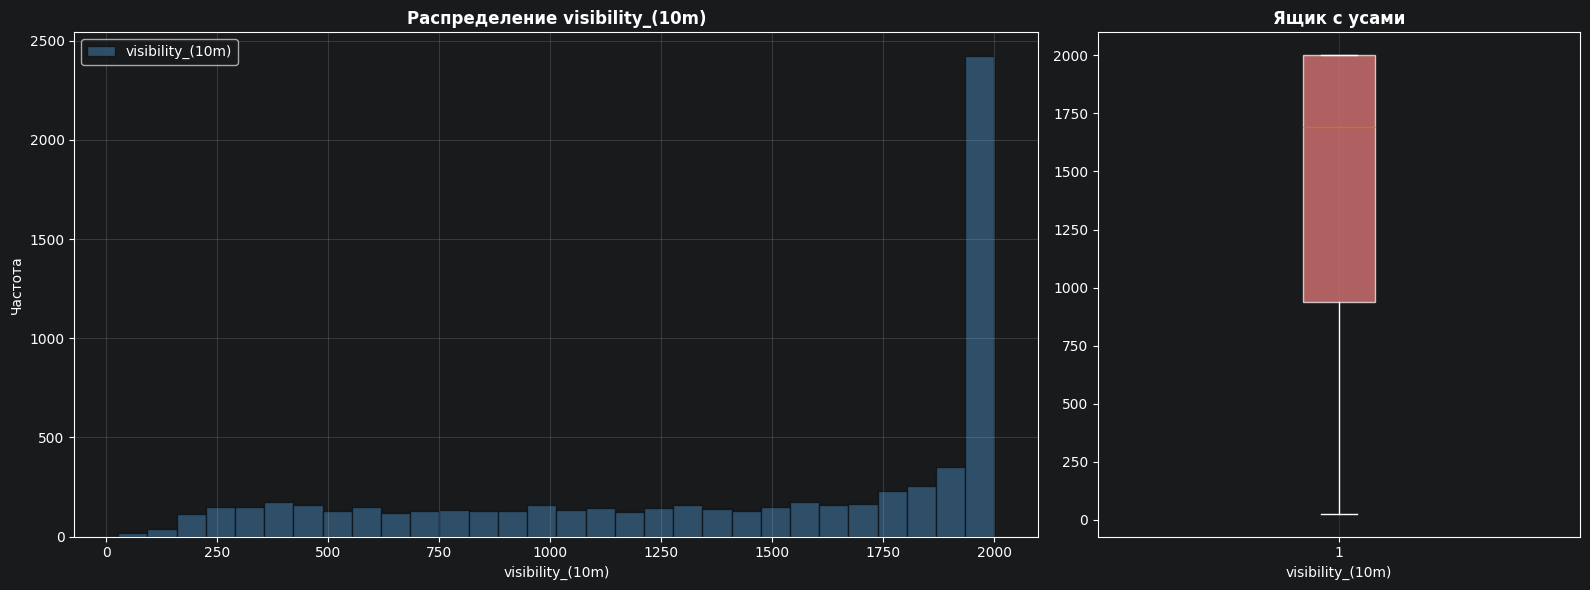

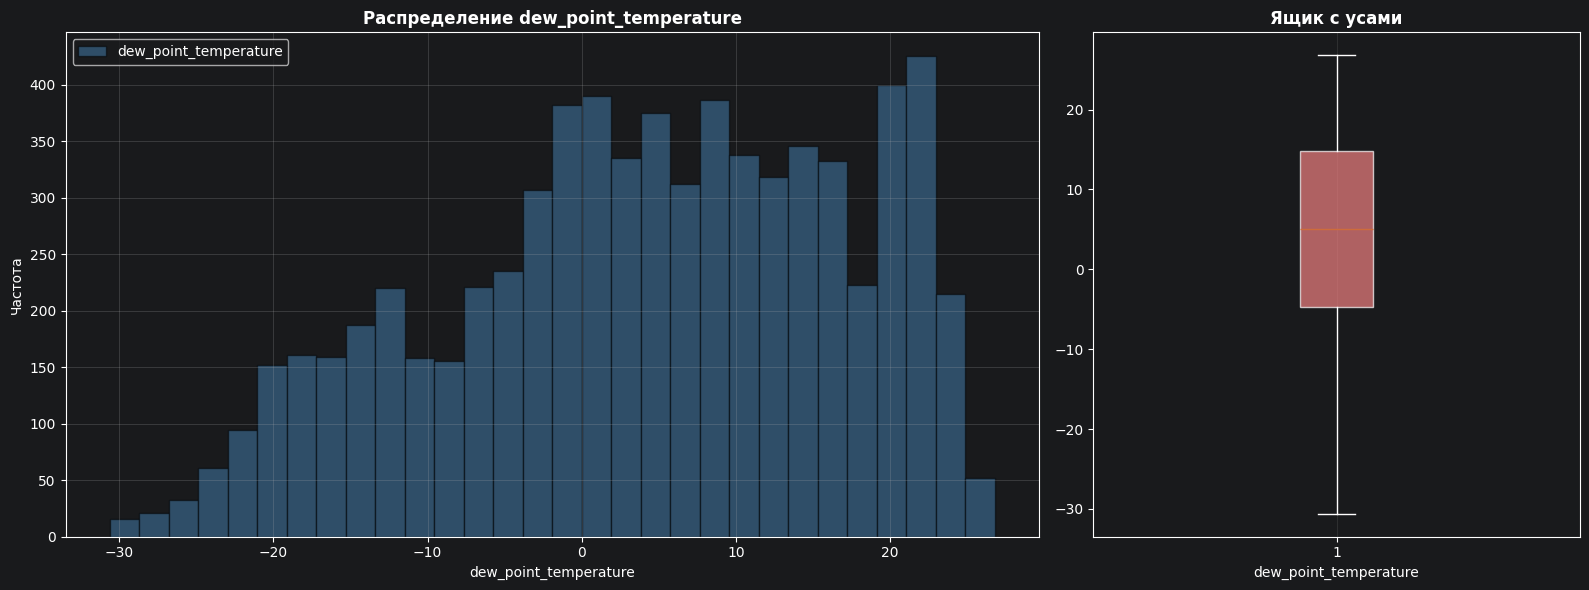

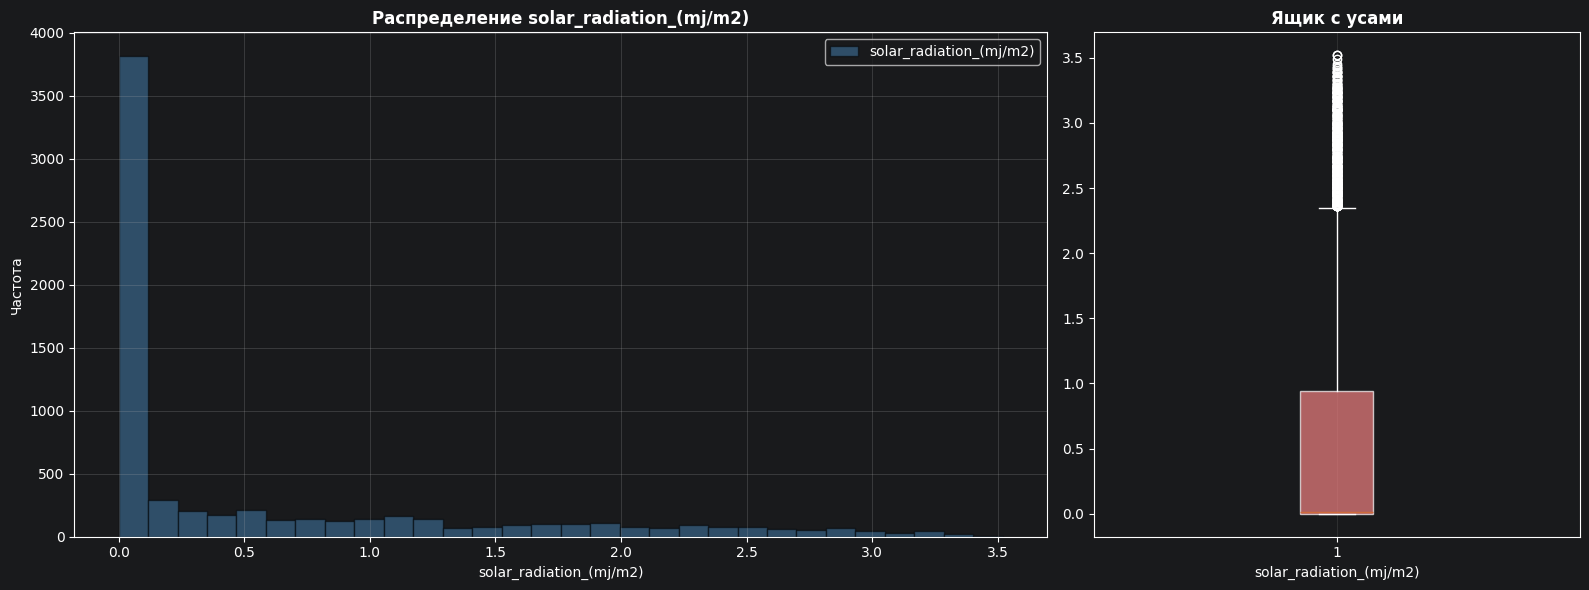

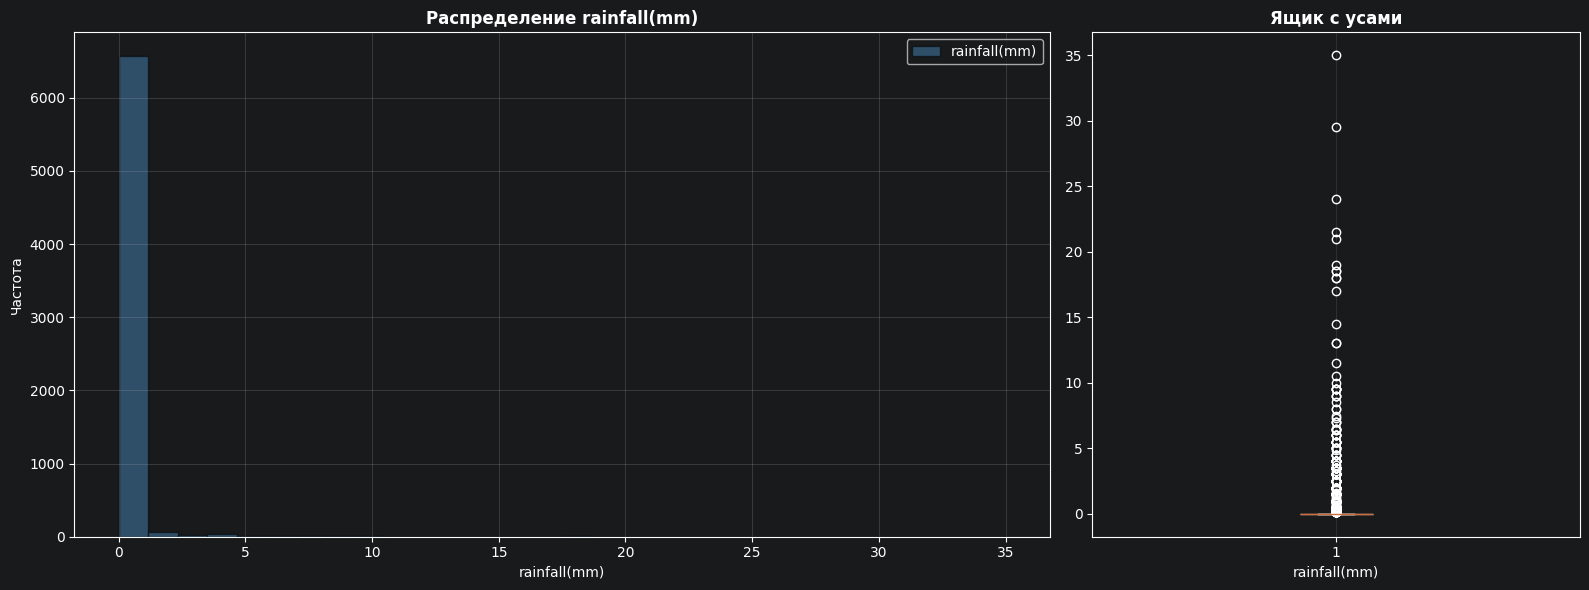

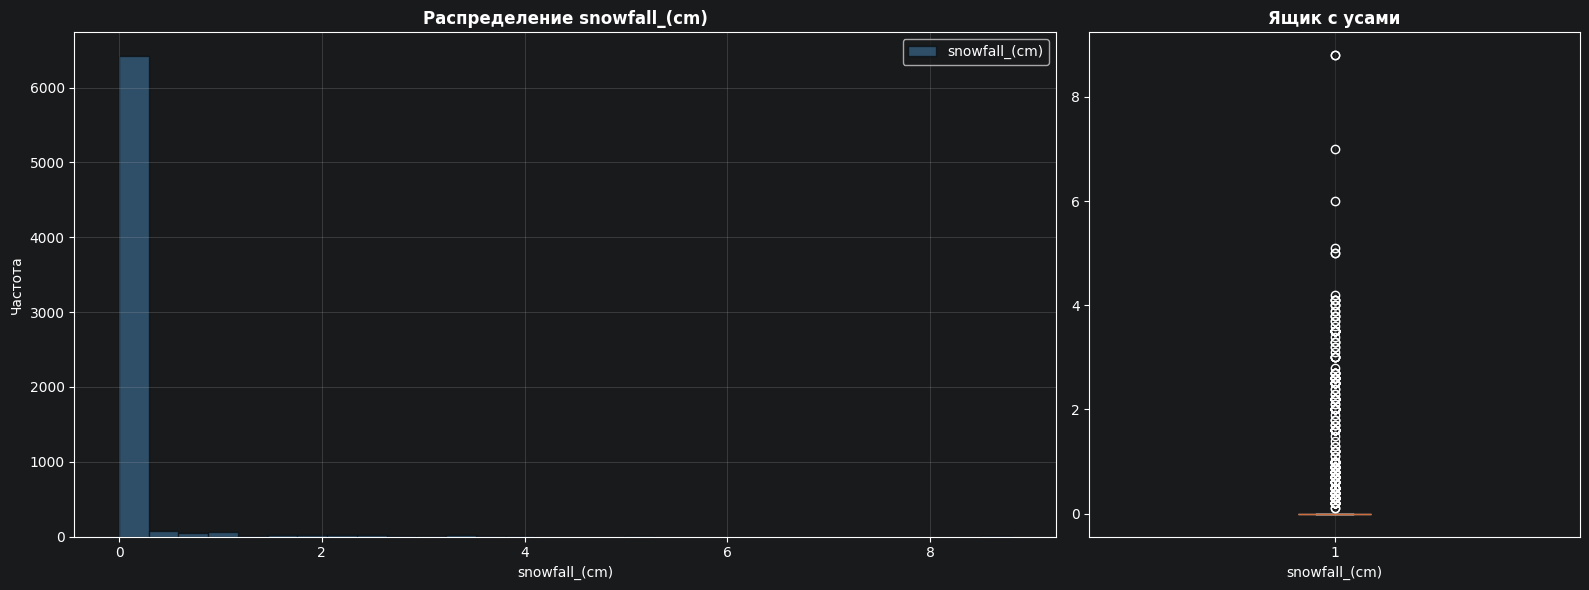

In [25]:
# Распределение чисельных признаков
numeric_features = [
    'temperature',
    'humidity(%)',
    'wind_speed_(m/s)',
    'visibility_(10m)',
    'dew_point_temperature',
    'solar_radiation_(mj/m2)',
    'rainfall(mm)',
    'snowfall_(cm)'
]
plot_distribution(X_train, numeric_features, bins=30, density=False)

In [26]:
def plot_cat_distribution(categorical_features):
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    axes = axes.ravel()

    for idx, feature in enumerate(categorical_features):
        sns.boxplot(data=df_train, x=feature, y='rented_bike_count',
                    ax=axes[idx], palette='Set2', hue=feature, legend=False, width=0.2)
        axes[idx].set_title(f'Распределение аренды по {feature}')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Количество аренд')
        axes[idx].tick_params(axis='x')

    for idx in range(len(categorical_features), len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

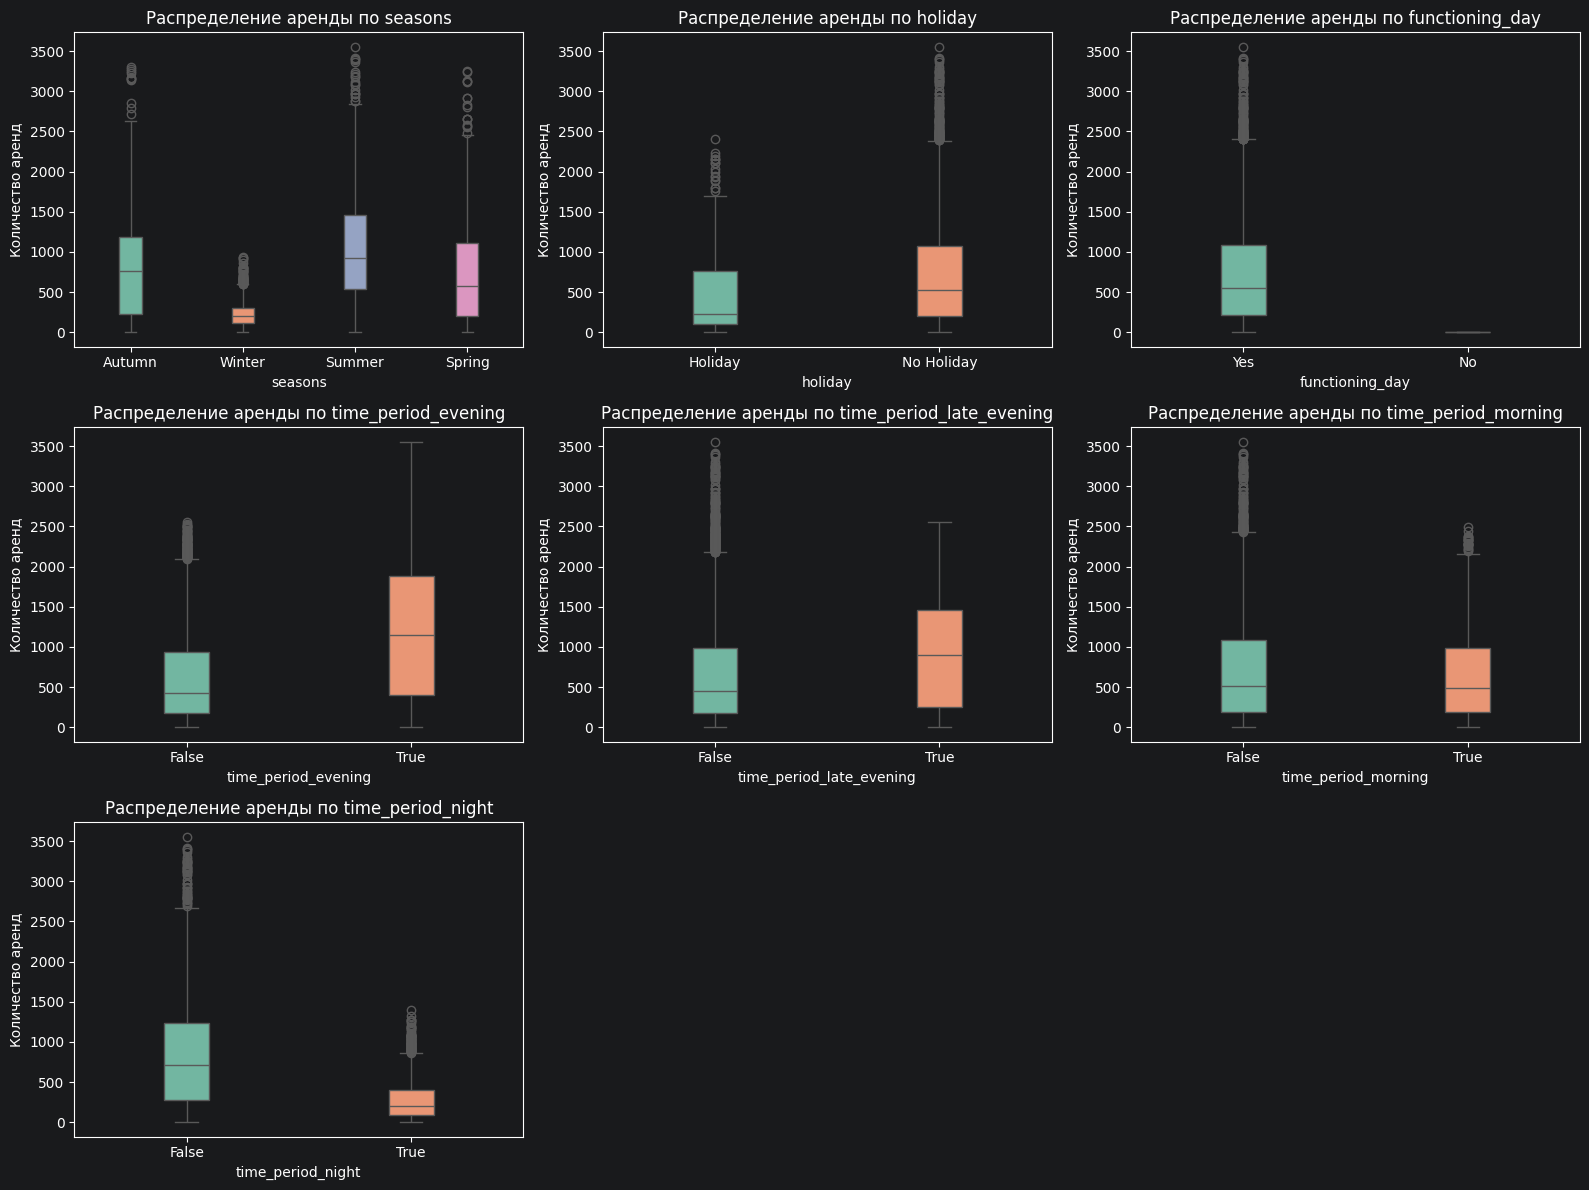

In [27]:
# Распределение аренды велосипедов в зависимости от категориальных признаков
categorical_features = [
    'seasons',
    'holiday' ,
    'functioning_day',
    'time_period_evening',
    'time_period_late_evening',
    'time_period_morning',
    'time_period_night',
]
plot_cat_distribution(categorical_features)

#### 2.2.6 Корреляции

In [28]:
columns = df_train.columns.tolist()
correlation_matrix = phik.phik_matrix(df_train[columns], interval_cols=numeric_features + ['rented_bike_count'], bins=5, verbose=False)

In [29]:
# Строим тепловую карту коэффициента phi_k
def plot_heatmap(corr_matrix):
    plt.figure(figsize=(30, 20))
    sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
               )
    plt.title('Тепловая карта коэффициента phi_k')
    plt.show()

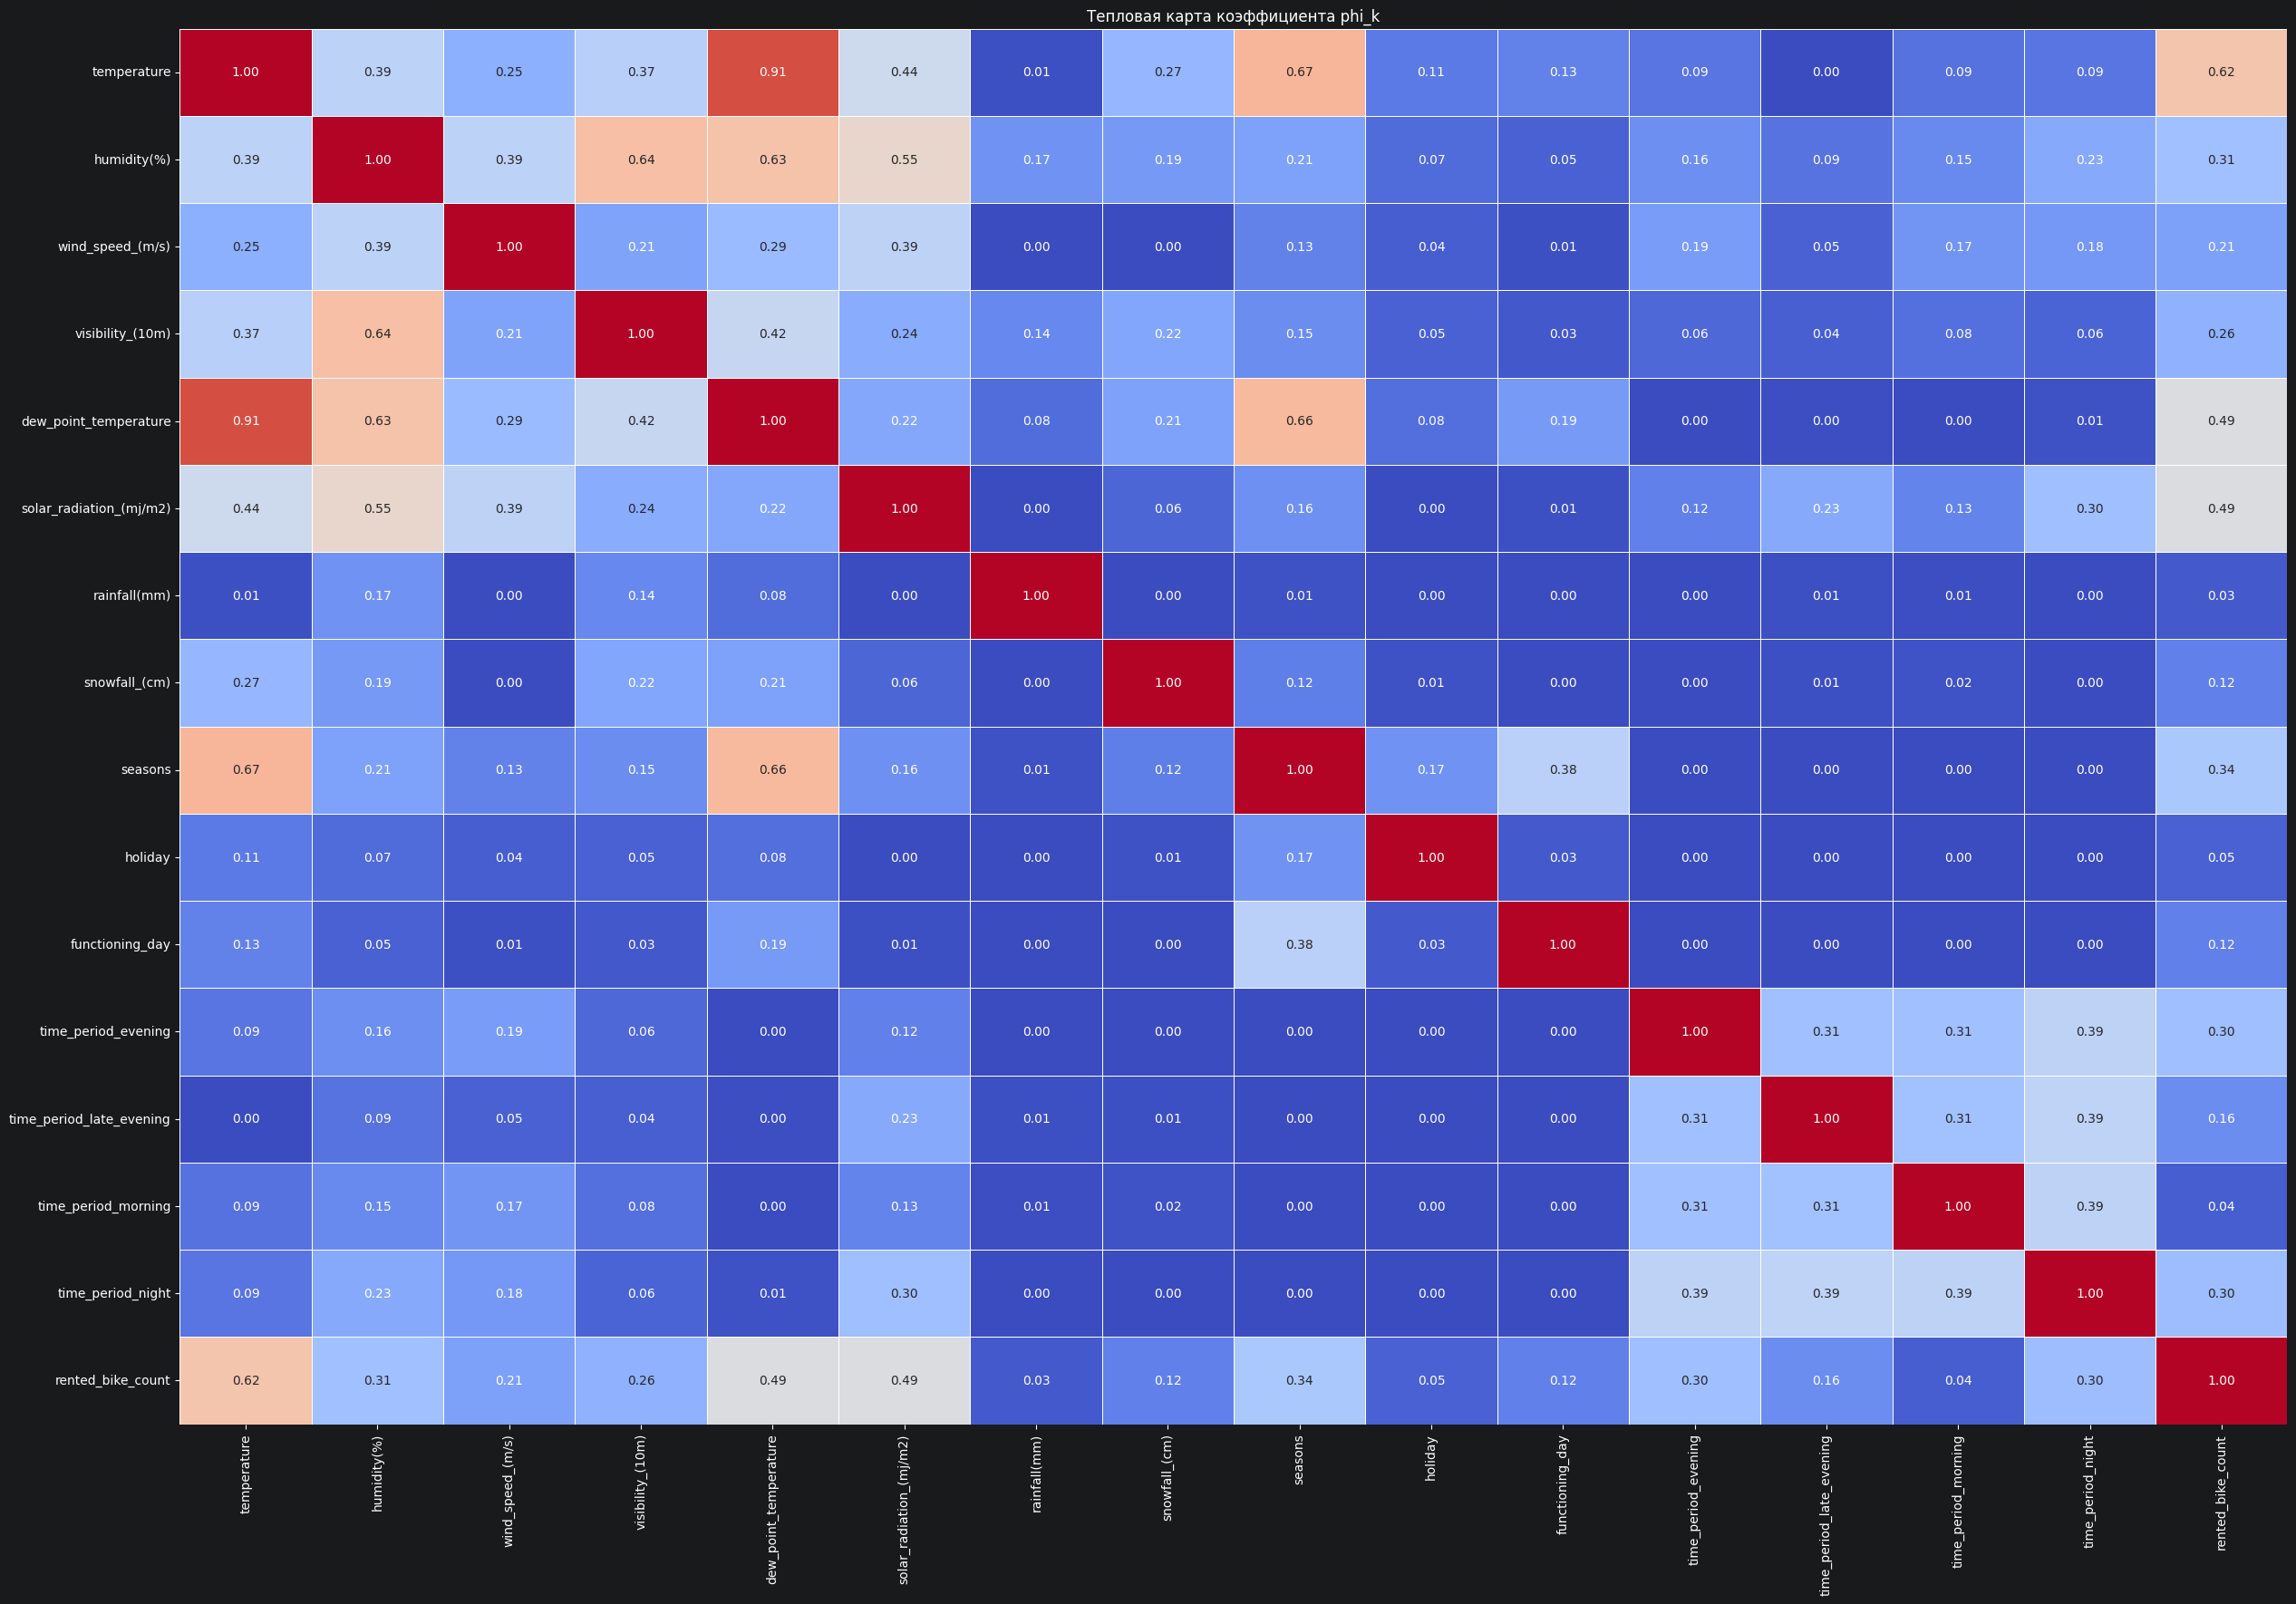

In [30]:
# Строим тепловую карту коэффициента phi_k
plot_heatmap(correlation_matrix)

In [31]:
# создаем список с параметрами с высокой корреляцией между признаками
high_corr_all_features = ['dew_point_temperature',]

In [32]:
rent_corr = correlation_matrix['rented_bike_count'].drop('rented_bike_count')
threshold = 0.02
low_threshold = 0.02
high_corr_features = rent_corr[rent_corr >= threshold]
zero_corr_features = rent_corr[rent_corr < low_threshold]

In [33]:
print(f"Признаки с корреляцией > {threshold}:")
display(high_corr_features.sort_values(ascending=False).head(10))
print(f"\nПризнаки с корреляцией <= {low_threshold}:")
display(zero_corr_features.sort_values(ascending=False))

Признаки с корреляцией > 0.02:


temperature                 0.624161
dew_point_temperature       0.490378
solar_radiation_(mj/m2)     0.488843
seasons                     0.336640
humidity(%)                 0.307714
time_period_evening         0.302807
time_period_night           0.296102
visibility_(10m)            0.257811
wind_speed_(m/s)            0.205267
time_period_late_evening    0.155888
Name: rented_bike_count, dtype: float64


Признаки с корреляцией <= 0.02:


Series([], Name: rented_bike_count, dtype: float64)

Самая высокая корреляция с целевым признаком `temperature`, `dew_point_temperature`, `solar_radiation_(mj/m2)`, `seasons`. Признаки без корреляции с целевой переменной в датасете отсутствуют.

In [34]:
# Создаем список с признаками для удаления
features_to_drop = zero_corr_features.index.tolist() + high_corr_all_features

#### 2.2.7 Выводы по EDA

В процессе исследования данных выделен признак с сильной связью `temperature`, так же есть пять признаков со средней связью `dew_point_temperature`, `solar_radiation_(mj/m2)`, `seasons`, `humidity(%)` и `time_period_evening`, остальные признаки с низкой связью. При этом обнаружено, что у признаков `temperature` и `dew_point_temperature` сильные связи между собой, что говорит нам о колинеарности и возможной нестабильности весов для целевой переменной. Избыточные фичи добавлены в переменную features_to_drop.

Наибольее значимые признаки для модели:

- temperature                 0.62
- dew_point_temperature       0.49
- solar_radiation_(mj/m2)     0.48
- seasons                     0.33
- humidity(%)                 0.30
- time_period_evening         0.30

Дальнейшие действия по предобработке данных: Числовые признаки нужно масштабировать `StandardScaler` или `MinMaxScaler`. Категориальные признаки с числом уникальных значений < 10 закодируем при помощи `OneHotEncoder`. Признак `season` трансформируем в циклический признак sin/cos [1, 2, 3, 4].

**Шаг 3. Обучение новых моделей**

kNN и деревья решений могут уловить нелинейные зависимости, недоступные линейной регрессии. Пора это проверить!

1. Подготовьте пайплайн для каждой модели:
    * Выполните предобработку данных.
    * Инициализизируйте регрессионные модели kNN и дерево решений.
4. Настройте базовые параметры моделей — например, `n_neighbors` для kNN, `max_depth` для дерева.

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров вы сделаете на следующем шаге.

---



### 2.3 Обучение KNN и Decision Tree

In [35]:
#Трансформер для числовых данных в зависимости от сезона
class SeasonsMedianImputer(BaseEstimator, TransformerMixin):

    def __init__(self, group_col, columns):
        self.group_col = group_col
        self.columns = columns
        self.group_medians_ = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.group_medians_[col] = X.groupby(self.group_col)[col].median().to_dict()
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns:
            for idx in X_copy[X_copy[col].isna()].index:
                group_value = X_copy.loc[idx, self.group_col]
                X_copy.loc[idx, col] = self.group_medians_[col][group_value]
        X_copy = X_copy.drop(columns=[self.group_col])
        return X_copy


In [36]:
#Создадим пайплайн для числовых признаков
num_features = [
    'temperature',
    'humidity(%)',
    'wind_speed_(m/s)',
    'visibility_(10m)',
    'dew_point_temperature',
    'solar_radiation_(mj/m2)',
    'rainfall(mm)',
    'snowfall_(cm)'
]

num_pipeline = Pipeline(steps=[
    ('imputer', SeasonsMedianImputer(group_col='seasons', columns=num_features)),
    ('scaler', StandardScaler()),
])

In [37]:
#Трансформер для преобразования категорий в бинарный тип данных
class BoolTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, columns=None):
        self.columns = columns
        self.mapping = {
            'Holiday': True, 'No Holiday': False,
            'Yes': True, 'No': False
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns:
            X_copy[col] = X_copy[col].map(self.mapping)
            X_copy[col] = X_copy[col].astype(bool)
        return X_copy

In [38]:
#Создадим пайплайн для бинарных признаков
bool_features = [
    'holiday',
    'functioning_day',
    'time_period_evening',
    'time_period_late_evening',
    'time_period_morning',
    'time_period_night',
]

bool_pipeline = Pipeline(steps=[
    ('to_bool', BoolTransformer(columns=['holiday', 'functioning_day'])),
    ('scaler', StandardScaler()),
])

In [39]:
#Создадим пайплайн для категориальных признаков
cat_features = [
    'seasons',
]

cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features + ['seasons']),
        ('bool', bool_pipeline, bool_features),
        ('cat', cat_pipeline, cat_features),
    ],
    remainder='drop',
)

In [41]:
model_results_df = pd.DataFrame({
    'model': [],
})

# Метрики для оценки
scoring = [
    'neg_root_mean_squared_error',
    'neg_mean_squared_error',
    'r2'
]

def model_metric(cv_result, tmp_pipeline, time_spent, tmp_scoring, modificator=None):
    model_name = tmp_pipeline.named_steps['regressor'].__class__.__name__
    if modificator:
        model_name = model_name + ' ' + modificator
    print(f'\n--- Средние Метрики {model_name} Модели (CV) ---')
    res_metrics = {}
    res_metrics['model'] = model_name
    metric_map = {
        'root_mean_squared_error': 'RMSE',
        'mean_squared_error': 'MSE',
        'r2': 'R2',
    }
    for metric in tmp_scoring:
        mean_value = cv_result[f'test_{metric}'].mean()
        std_value = cv_result[f'test_{metric}'].std()
        if metric.startswith('neg_'):
            metric = metric.replace('neg_', '')
            mean_value = -mean_value
        metric = metric_map[metric]

        print(f'{metric}: {mean_value:.3f} (±{std_value*2:.3f})')
        res_metrics[metric] = f'{mean_value:.3f}'
        res_metrics[f'{metric} dev'] = f'±{std_value*2:.3f}'


    tmp_df = pd.DataFrame([res_metrics])
    print(f'Затрачено времени: {time_spent:.2f} сек.')
    return tmp_df

In [42]:
#Кроссвалидация LogReg модели
cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

start_time = time()
cv_res = cross_validate(loaded_pipeline, X_train_init, y_train_init, scoring=scoring, cv=cv)
end_time = time()

lr_metrics = model_metric(cv_res, loaded_pipeline, end_time - start_time, scoring)
model_results_df = pd.concat([model_results_df, lr_metrics], ignore_index=True)
lr_metrics


--- Средние Метрики LinearRegression Модели (CV) ---
RMSE: 413.901 (±6.289)
MSE: 171323.846 (±5215.727)
R2: 0.589 (±0.020)
Затрачено времени: 0.08 сек.


,model,RMSE,RMSE dev,MSE,MSE dev,R2,R2 dev
0,LinearRegression,413.901,±6.289,171323.846,±5215.727,0.589,±0.020


#### 2.3.1 Обучение KNeighborsRegressor

In [43]:
#Кроссвалидация KNN модели
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5))
])

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

start_time = time()
cv_res = cross_validate(knn_pipeline, X_train, y_train, scoring=scoring, cv=cv)
end_time = time()

knn_metrics = model_metric(cv_res, knn_pipeline, end_time - start_time, scoring)
model_results_df = pd.concat([model_results_df, knn_metrics], ignore_index=True)
knn_metrics


--- Средние Метрики KNeighborsRegressor Модели (CV) ---
RMSE: 322.359 (±14.434)
MSE: 103967.139 (±9280.477)
R2: 0.751 (±0.024)
Затрачено времени: 0.48 сек.


,model,RMSE,RMSE dev,MSE,MSE dev,R2,R2 dev
0,KNeighborsRegressor,322.359,±14.434,103967.139,±9280.477,0.751,±0.024


#### 2.3.2 Обучение DecisionTreeRegressor

In [44]:
#Кроссвалидация Decision Tree модели
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=5))
])

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

start_time = time()
cv_res = cross_validate(dt_pipeline, X_train, y_train, scoring=scoring, cv=cv)
end_time = time()

dt_metrics = model_metric(cv_res, dt_pipeline, end_time - start_time, scoring)
model_results_df = pd.concat([model_results_df, dt_metrics], ignore_index=True)
dt_metrics


--- Средние Метрики DecisionTreeRegressor Модели (CV) ---
RMSE: 380.851 (±19.901)
MSE: 145146.873 (±14918.286)
R2: 0.652 (±0.032)
Затрачено времени: 0.40 сек.


,model,RMSE,RMSE dev,MSE,MSE dev,R2,R2 dev
0,DecisionTreeRegressor,380.851,±19.901,145146.873,±14918.286,0.652,±0.032


#### 2.3.3 Сравнение моделей
Базовая модель KNeighborsRegressor значительно лучше чем предоставленная модель LogisticRegressor предсказывает спрос по ключевой метрике RMSE 322 (±14) против 412. Базовая модель DecisionTreeRegressor показывает результат хуже (RMSE 381 (±17)), чем KNeighborsRegressor, но лучше LogisticRegression.

### 2.4 Подбор гиперпараметров

**Шаг 4. Подбор гиперпараметров с Optuna**

Компания хочет точную модель. Optuna поможет найти лучшие гиперпараметры для kNN и дерева, чтобы снизить ошибки прогноза.


1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь сначала экспериментировать с небольшими диапазонами, а потом расширять их, если модель не уловит зависимости.

---



#### 2.4.1 Подбор гиперпараметров с Optuna

In [45]:
#Подбор гиперпараметров для KNeighborsRegressor
cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    # Пространство поиска гиперпараметров
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 30),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric': trial.suggest_categorical('metric', ['minkowski']),
        'p': trial.suggest_int('p', 1, 4),
        'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree']),
        'leaf_size': trial.suggest_int('leaf_size', 20, 50),
    }

    model = KNeighborsRegressor(**params)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
        ])

    scorer = make_scorer(root_mean_squared_error)

    scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scorer
    )

    return scores.mean()

# Запуск исследования
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Лучшие гиперпараметры и качество
knn_best_params = study.best_params
print('Лучшие гиперпараметры:', knn_best_params)
knn_best_value = study.best_value
print('Лучшее среднее значение RMSE на кросс-валидации:', knn_best_value)

[I 2026-04-16 15:05:17,244] A new study created in memory with name: no-name-54c0cf85-6ac7-4f17-a6b0-2bc40d8b3873


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-16 15:05:18,135] Trial 0 finished with value: 320.50117960852987 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'metric': 'minkowski', 'p': 3, 'algorithm': 'auto', 'leaf_size': 46}. Best is trial 0 with value: 320.50117960852987.
[I 2026-04-16 15:05:19,189] Trial 1 finished with value: 328.58357590973395 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'metric': 'minkowski', 'p': 4, 'algorithm': 'auto', 'leaf_size': 25}. Best is trial 0 with value: 320.50117960852987.
[I 2026-04-16 15:05:19,873] Trial 2 finished with value: 316.3818516024585 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'metric': 'minkowski', 'p': 2, 'algorithm': 'auto', 'leaf_size': 31}. Best is trial 2 with value: 316.3818516024585.
[I 2026-04-16 15:05:22,513] Trial 3 finished with value: 321.981786741621 and parameters: {'n_neighbors': 15, 'weights': 'uniform', 'metric': 'minkowski', 'p': 3, 'algorithm': 'kd_tree', 'leaf_size': 25}. Best is trial 2 with value: 316.381851602

In [46]:
# Визуализация результатов KNN
fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2)

In [47]:
#Подбор гиперпараметров для DecisionTreeRegressor
cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    # Пространство поиска гиперпараметров
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 5, 100),
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'absolute_error']),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.001, 0.1, log=True),
    }

    model = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
        ])

    scorer = make_scorer(root_mean_squared_error)

    scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scorer
    )

    return scores.mean()

# Запуск исследования
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Лучшие гиперпараметры и качество
dt_best_params = study.best_params
print('Лучшие гиперпараметры:', dt_best_params)
dt_best_value = study.best_value
print('Лучшее среднее значение RMSE на кросс-валидации:', dt_best_value)

[I 2026-04-16 15:05:58,998] A new study created in memory with name: no-name-33f5e531-296d-4de0-86ee-6ea447861ce1


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-16 15:05:59,434] Trial 0 finished with value: 338.41350715813786 and parameters: {'max_depth': 7, 'min_samples_split': 48, 'min_samples_leaf': 15, 'max_leaf_nodes': 62, 'criterion': 'squared_error', 'ccp_alpha': 0.0013066739238053278}. Best is trial 0 with value: 338.41350715813786.
[I 2026-04-16 15:05:59,855] Trial 1 finished with value: 444.22803644766327 and parameters: {'max_depth': 14, 'min_samples_split': 31, 'min_samples_leaf': 15, 'max_leaf_nodes': 6, 'criterion': 'squared_error', 'ccp_alpha': 0.0026587543983272706}. Best is trial 0 with value: 338.41350715813786.
[I 2026-04-16 15:06:00,278] Trial 2 finished with value: 380.435325536869 and parameters: {'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_leaf_nodes': 55, 'criterion': 'squared_error', 'ccp_alpha': 0.016738085788752126}. Best is trial 0 with value: 338.41350715813786.
[I 2026-04-16 15:06:00,685] Trial 3 finished with value: 423.63049629729414 and parameters: {'max_depth': 4, 'min_sampl

In [48]:
# Визуализация результатов Decision Tree
fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2)

**Шаг 5. Кросс-валидация новых моделей**

1. Проведите кросс-валидацию kNN и дерева решений с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (например, столбчатую диаграмму или ящик с усами), чтобы оценить разброс метрик и стабильность моделей.


---



#### 2.5 Сравнение с линейной моделью
#### 2.5.1 Кросс-валидация новых моделей

In [49]:
#Кроссвалидация KNN модели с лучшими гиперпараметрами
best_knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(**knn_best_params))
])

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

start_time = time()
cv_res = cross_validate(best_knn_pipeline, X_train, y_train, scoring=scoring, cv=cv)
end_time = time()

best_knn_metrics = model_metric(cv_res, best_knn_pipeline, end_time - start_time, scoring, 'best')
model_results_df = pd.concat([model_results_df, best_knn_metrics], ignore_index=True)
best_knn_metrics


--- Средние Метрики KNeighborsRegressor best Модели (CV) ---
RMSE: 305.362 (±11.994)
MSE: 93281.674 (±7342.089)
R2: 0.776 (±0.018)
Затрачено времени: 0.60 сек.


,model,RMSE,RMSE dev,MSE,MSE dev,R2,R2 dev
0,KNeighborsRegressor best,305.362,±11.994,93281.674,±7342.089,0.776,±0.018


In [50]:
#Кроссвалидация Decision Tree модели с лучшими гиперпараметрами
best_dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=RANDOM_STATE, **dt_best_params))
])

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

start_time = time()
cv_res = cross_validate(best_dt_pipeline, X_train, y_train, scoring=scoring, cv=cv)
end_time = time()

best_dt_metrics = model_metric(cv_res, best_dt_pipeline, end_time - start_time, scoring, 'best')
model_results_df = pd.concat([model_results_df, best_dt_metrics], ignore_index=True)
best_dt_metrics


--- Средние Метрики DecisionTreeRegressor best Модели (CV) ---
RMSE: 316.961 (±11.599)
MSE: 100497.619 (±7327.868)
R2: 0.759 (±0.019)
Затрачено времени: 0.43 сек.


,model,RMSE,RMSE dev,MSE,MSE dev,R2,R2 dev
0,DecisionTreeRegressor best,316.961,±11.599,100497.619,±7327.868,0.759,±0.019


#### 2.5.2 Сравнение моделей

**Шаг 6. Составление отчёта по моделям**

1. Составьте таблицу с метриками для трёх моделей: baseline, лучшей kNN и лучшего дерева решений.
2. Добавьте визуализацию с распределением метрик, если необходимо.

Подготовьте выводы:
* Какая модель лучше справляется с прогнозом?
* Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте. Примеры выводов на языке заказчика:
* «Эта модель лучше реагирует на дождь».
* «Температура и влажность сильно влияют на спрос в пиковые часы».

---



In [51]:
# Таблица с метриками для обученых моделей
model_results_df = model_results_df.sort_values(by='RMSE')
model_results_df

,model,RMSE,RMSE dev,MSE,MSE dev,R2,R2 dev
3,KNeighborsRegressor best,305.362,±11.994,93281.674,±7342.089,0.776,±0.018
4,DecisionTreeRegressor best,316.961,±11.599,100497.619,±7327.868,0.759,±0.019
1,KNeighborsRegressor,322.359,±14.434,103967.139,±9280.477,0.751,±0.024
2,DecisionTreeRegressor,380.851,±19.901,145146.873,±14918.286,0.652,±0.032
0,LinearRegression,413.901,±6.289,171323.846,±5215.727,0.589,±0.020


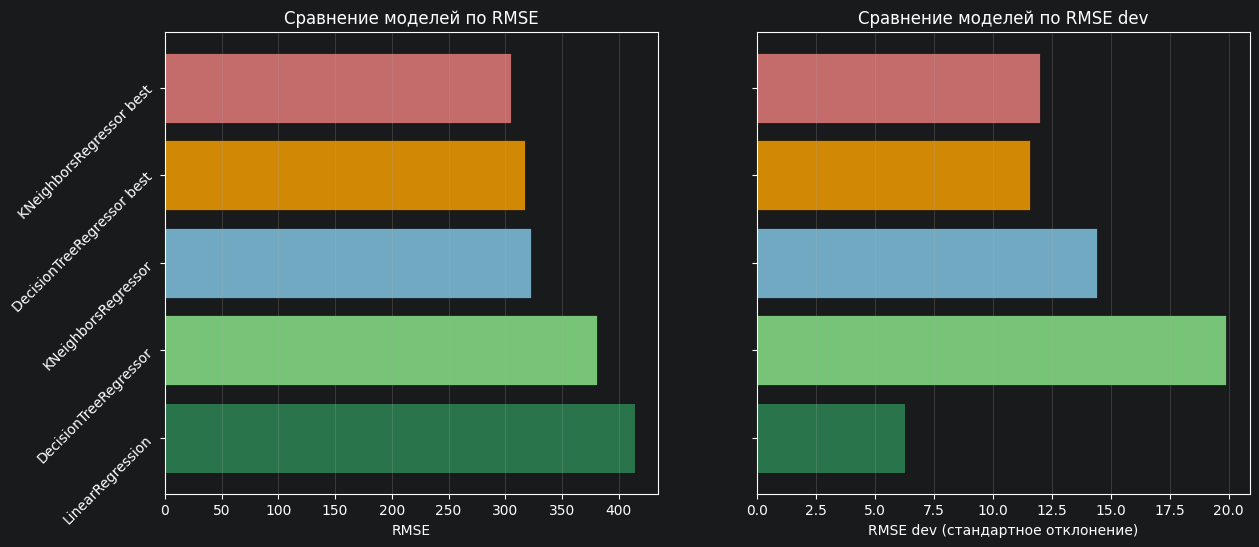

In [52]:
# Визуализация метрики RMSE для обученых моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rmse = model_results_df['RMSE'].astype(float)

colors = ['lightcoral', 'orange', 'skyblue', 'lightgreen', 'seagreen']
axes[0].barh(range(0, len(model_results_df), 1), rmse,
                     color=colors, capsize=3, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(model_results_df)))
axes[0].set_yticklabels(model_results_df['model'], rotation=45)
axes[0].set_title('Сравнение моделей по RMSE')
axes[0].set_xlabel('RMSE')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

rmse_dev = model_results_df['RMSE dev'].str.split('±').str[1].astype(float)
axes[1].barh(range(0, len(model_results_df), 1), rmse_dev,
                     color=colors,  alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(len(model_results_df)))
axes[1].set_yticklabels([])
axes[1].set_xlabel('RMSE dev (стандартное отклонение)')
axes[1].set_title('Сравнение моделей по RMSE dev')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

Оптимизированная модель KNN показала сильное улучшение в сравнении с LogReg 305 против 413 по ключевой метрике RMSE, KNN объясняет 77.6% данных против 58.9% у LogReg. Оптимизированная модель DecisionTree показала результаты немного хуже чем KNN, 316 против 305 по RMSE и 75.9% против 77.6%.

### 2.6 Выводы


In [53]:
# Выводим коэффициенты для модели линейной регрессии
coefficients = loaded_pipeline.named_steps['regressor'].coef_
preprocessor = loaded_pipeline.named_steps['preprocessor']
feature_names_after = preprocessor.get_feature_names_out()
lr_feature_importance = pd.DataFrame({
    'feature': feature_names_after,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)
lr_feature_importance

,feature,abs_coefficient
16,ohe_pass__Time_Period_Evening,517.597731
14,str_cat__Functioning Day_No,469.058969
15,str_cat__Functioning Day_Yes,469.058969
17,ohe_pass__Time_Period_Late Evening,410.511706
0,num__Temperature,283.305350
18,ohe_pass__Time_Period_Morning,239.624847
11,str_cat__Seasons_Winter,191.550389
8,str_cat__Seasons_Autumn,164.091914
1,num__Humidity(%),142.566979
19,ohe_pass__Time_Period_Night,118.403949


In [60]:
# Выводим важность признаков для модели KNN
best_knn_pipeline.fit(X_train, y_train)

importance_result = permutation_importance(
    best_knn_pipeline, X_test, y_test,
    n_repeats=10,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

knn_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance_result.importances_mean,
}).sort_values('importance', ascending=False)
knn_feature_importance

,feature,importance
11,time_period_evening,102.652064
10,functioning_day,87.889491
12,time_period_late_evening,78.228588
0,temperature,52.379420
1,humidity(%),47.873588
8,seasons,36.447227
5,solar_radiation_(mj/m2),29.922627
4,dew_point_temperature,25.926279
3,visibility_(10m),20.654797
6,rainfall(mm),19.015178


В соответствии с целевой метрикой RMSE, лучшая модель KNN c наименьшей ошибкой ~305, а так же данная модель объясняет 77.6% данных.
KNN модель лучше реагирует на показатели влажности, солнечную радиацию, точку росы и видимость в сравнении с линейной моделью. спрос на велосипеды выше когда влажность в оптимальную влажность 40-70%, когда солнечная радиация менее 1.0 МДж/м², видимость более 1000м, точка росы от -5 до 15 градусов C.

---

На предсказание спроса на аренду велосипедов большее влияние оказывают признаки:
- time_period_evening
- functioning_day
- time_period_late_evening
- temperature
- humidity(%)
- seasons
- solar_radiation_(mj/m2)
- dew_point_temperature
---
Модель можно рекомендовать к использованию в продакшене.

### Подготовка артефактов модели для внедрения

**Шаг 7. Сохранение модели и отчёта**

1. Выберите финальную, лучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько хорошо она прогнозирует на новых данных.
2. Подготовьте тетрадку с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг. Объясняйте, почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче эта привычка поможет вашим коллегам и руководству понимать решения и доверять модели.

---



In [59]:
# Оценка модели на тестовой выборке
evaluate_model(best_knn_pipeline, X_test, y_test, False)

RMSE на тестовой выборке: 311.892
MSE на тестовой выборке: 97276.584
R2 на тестовой выборке: 0.762


Exception ignored in: <function ResourceTracker.__del__ at 0x10b68f600>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1075c7600>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3

Модель хорошо справляется с предсказаниями на новых данных, так как ключевые метрики немного уступают метрикам на тестовой выборке, 305 RMSE на тренировочной выборке и 311 на тестовой. Разница с тренировочной выборкой в объясняющей способности около 1%.

In [56]:
version = '1'
date = '16-04-2026'
model_name = f'bike_count_predictor_v{version}_{date}.joblib'
rmse = model_results_df.sort_values(by='RMSE', ascending=True)['RMSE'].iloc[0]

metadata = {
    'model_version': version,
    'training_date': date,
    'rmse': rmse,
    'parameters': knn_best_params,
    'requirements': {
        'ipykernel>=7.2.0',
        'jinja2==3.1.6',
        'joblib==1.3.0',
        'matplotlib==3.10.8',
        'nbformat>=5.10.4',
        'numpy==2.4.3',
        'pandas==3.0.1',
        'phik==0.12.5',
        'plotly>=6.7.0',
        'scikit-learn==1.6.1',
        'seaborn==0.13.2',
    }
}

joblib.dump({
    'pipeline': best_knn_pipeline,
    'metadata': metadata
}, model_name)

['bike_count_predictor_v1_16-04-2026.joblib']

In [57]:
#Загрузка пайплайна из файла
loaded_knn_pipeline = joblib.load(model_name).get('pipeline')

In [58]:
prediction = loaded_knn_pipeline.predict(X_test.iloc[[0]])
prediction[0]

np.float64(298.7721068943625)

https://github.com/msesemov/DS_kNN_DecisionTree_Sprint_14.git

**Дополнительное задание: реализация кастомного трансформера**

Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию. Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

1. Реализуйте класс с методами `fit` и `transform`.
2. Вставьте его в пайплайн перед моделью.
3. Убедитесь, что трансформер корректно работает с тренировочными данными.

**Совет:**  
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---

